# Learn PyTorch

In [60]:
from typing import Any, Iterable, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

## 1 Working with Data

### 1.1 Download data

In [61]:
# Download training data from open datasets
dataset_train = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True,
)

# Download test data from open datasets
dataset_test = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    download=True,
)

print(f"train: {len(dataset_train)}, test: {len(dataset_test)}")

train: 60000, test: 10000


### 1.2 Visualize Data

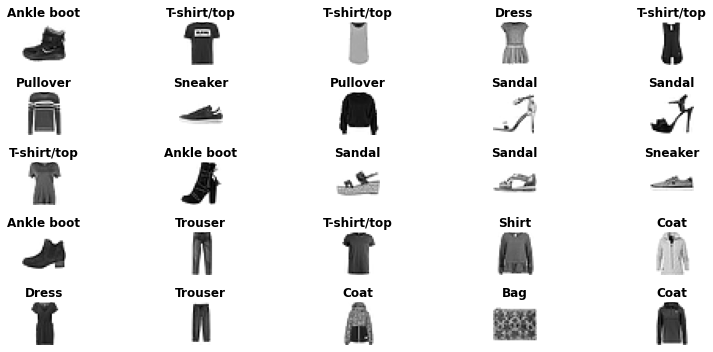

In [62]:
classes = [
    "T-Shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]


def plot_images(
    images: Iterable[Any],
    classes: Sequence[str],
    n_samples: int,
    n_cols: int = 5,
    figsize: Tuple[float, float] = (12, 5),
) -> plt.Figure:
    n_row = int(np.ceil(n_samples / n_cols))

    fig, axs = plt.subplots(nrows=n_row, ncols=n_cols, squeeze=False, figsize=figsize)
    for ax, (img, label) in zip(axs.ravel(), images):
        ax.imshow(img.squeeze(), cmap="gray_r")
        ax.set_title(classes[label], fontsize="large", fontweight="bold")
        ax.axis("off")

    fig.tight_layout()
    plt.show()

    return fig


plot_images(dataset_train, classes=dataset_train.classes, n_samples=25);

### 1.3 Data Loader

In [63]:
batch_size = 64

# Create data loaders
dataloader_train = DataLoader(dataset=dataset_train, batch_size=batch_size)
dataloader_test = DataLoader(dataset=dataset_test, batch_size=batch_size)

for X, y in dataloader_test:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64])


## 2 Creating Models
### 2.1 Get cpu or gpu device for training.

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 2.2 Define Model

In [65]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


model = NeuralNetwork().to(device)

### 2.3 Inspect Model Structure

In [66]:
print(model)
print()

for name, params in model.named_parameters():
    print("Layer:", name)
    print("Size:", params.size())
    print(params)
    print()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

Layer: linear_relu_stack.0.weight
Size: torch.Size([512, 784])
Parameter containing:
tensor([[-0.0349,  0.0294,  0.0334,  ...,  0.0285,  0.0297,  0.0129],
        [-0.0287, -0.0224, -0.0062,  ...,  0.0150, -0.0297,  0.0265],
        [-0.0227, -0.0294, -0.0071,  ...,  0.0204, -0.0154, -0.0121],
        ...,
        [ 0.0046,  0.0108,  0.0092,  ..., -0.0261, -0.0155,  0.0275],
        [-0.0092, -0.0199,  0.0232,  ..., -0.0117,  0.0335, -0.0046],
        [ 0.0016, -0.0085, -0.0334,  ..., -0.0351,  0.0288, -0.0054]],
       device='cuda:0', requires_grad=True)

Layer: linear_relu_stack.0.bias
Size: torch.Size([512])
Parameter containing:
tensor([ 3.4626e-02, -3.4678e-02, -2.5

### 2.3 Inference without Training

In [67]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_prob = nn.Softmax(dim=1)(logits)
y_pred = pred_prob.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([4], device='cuda:0')


## 3 Optimizing the Model Parameters
### 3.1 Loss Functions and Optimizer

In [68]:
loss_fn = nn.CrossEntropyLoss()  # combines nn.LogSoftmax and nn.NLLLoss
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

### 3.2 Training Loop

In [69]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()  # reset the gradients of model parameters
        loss.backward()  # deposits the gradients of the loss w.r.t. each parameter
        optimizer.step()  # adjust the parameters by the gradients collected in the backward pass

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

### 3.3 Test Loop

In [70]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )

### 3.4 Actual Training Process

In [71]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train(dataloader_train, model, loss_fn, optimizer)
    test(dataloader_test, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.297447  [    0/60000]
loss: 2.295445  [ 6400/60000]
loss: 2.269144  [12800/60000]
loss: 2.265829  [19200/60000]
loss: 2.249815  [25600/60000]
loss: 2.207852  [32000/60000]
loss: 2.231855  [38400/60000]
loss: 2.189367  [44800/60000]
loss: 2.198245  [51200/60000]
loss: 2.143105  [57600/60000]
Test Error: 
 Accuracy: 22.3%, Avg loss: 2.146848 

Epoch 2
-------------------------------
loss: 2.158299  [    0/60000]
loss: 2.153840  [ 6400/60000]
loss: 2.081588  [12800/60000]
loss: 2.101499  [19200/60000]
loss: 2.059961  [25600/60000]
loss: 1.981769  [32000/60000]
loss: 2.029086  [38400/60000]
loss: 1.936906  [44800/60000]
loss: 1.955389  [51200/60000]
loss: 1.861680  [57600/60000]
Test Error: 
 Accuracy: 50.2%, Avg loss: 1.868241 

Epoch 3
-------------------------------
loss: 1.900558  [    0/60000]
loss: 1.874506  [ 6400/60000]
loss: 1.740622  [12800/60000]
loss: 1.788711  [19200/60000]
loss: 1.700543  [25600/60000]
loss: 1.632822  [32000/600

## 4 Saving Models

## 5 Loading Models